In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

## 1. A dataset that is NOT linearly separable

make_moons is a classic synthetic dataset: two classes that draw interlocking half-moons. *No straight line* can separate them correctly. No matter how we tune the weights, a linear boundary will misclassify points along the curve.

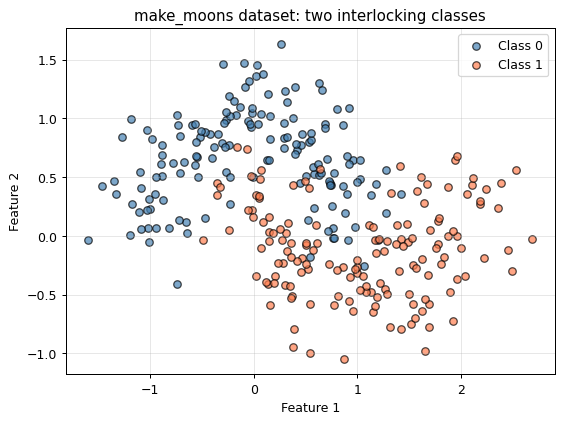

In [2]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', label='Class 1', alpha=0.7, edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('make_moons dataset: two interlocking classes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Logistic regression accuracy (test): 0.883


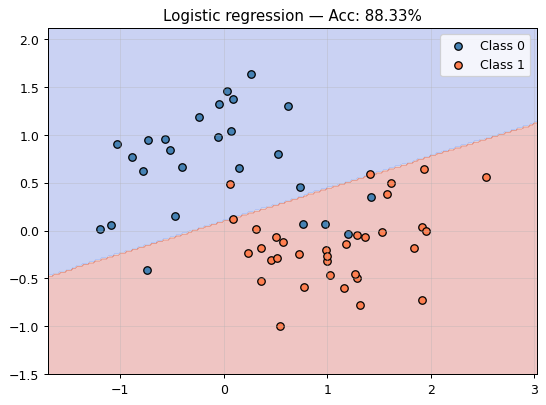

In [ ]:
def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
acc_logreg = accuracy_score(y_test, logreg.predict(X_test))

print(f'Logistic regression accuracy (test): {acc_logreg:.3f}')
plot_decision_boundary(logreg, X_test, y_test, f'Logistic regression — Acc: {acc_logreg:.2%}')

Logistic regression accuracy (test): 0.883


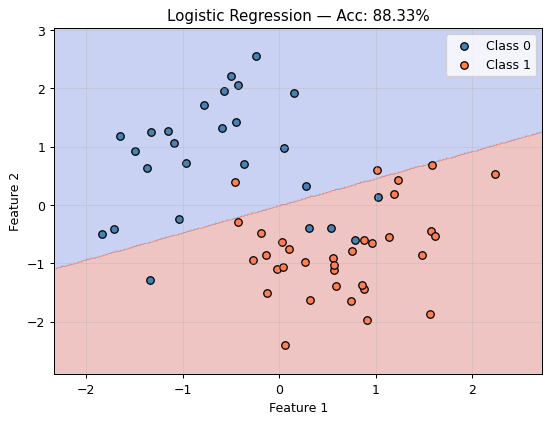

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo lineal
logreg = LogisticRegression(C=10)

# Entrenamiento
logreg.fit(X_train_scaled, y_train)

# Accuracy
acc_logreg = accuracy_score(
    y_test,
    logreg.predict(X_test_scaled)
)

print(f'Logistic regression accuracy (test): {acc_logreg:.3f}')


def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    
    h = 0.02

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    # Predicción
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(7, 5))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap='coolwarm'
    )

    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        c='steelblue',
        edgecolor='k',
        label='Class 0'
    )

    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        c='coral',
        edgecolor='k',
        label='Class 1'
    )

    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()


# Visualización
plot_decision_boundary(
    logreg,
    X_test_scaled,
    y_test,
    f'Logistic Regression — Acc: {acc_logreg:.2%}'
)

Polinomial Grado 3 (C=10) accuracy: 0.933


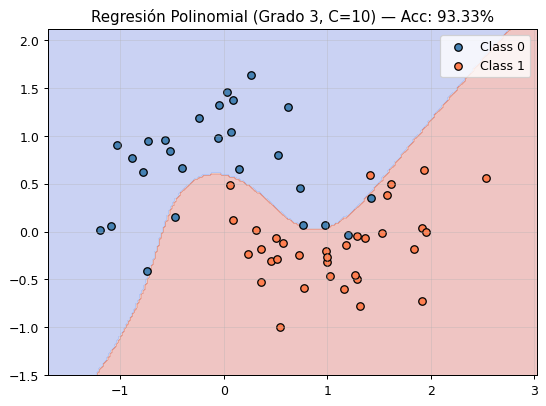

In [26]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# =====================================================================
# OPCIÓN A: Regresión Polinomial Grado 3 (Con C alta) -> Acc: 93.3%
# =====================================================================
poly_logreg_deg3 = Pipeline([
    ('polynomial_features', PolynomialFeatures(degree=3)),
    ('logistic_regression', LogisticRegression(C=10.0, max_iter=1000)) # <-- C=10 reduce la penalización
])

poly_logreg_deg3.fit(X_train, y_train)
acc_poly3 = accuracy_score(y_test, poly_logreg_deg3.predict(X_test))
print(f'Polinomial Grado 3 (C=10) accuracy: {acc_poly3:.3f}')
plot_decision_boundary(poly_logreg_deg3, X_test, y_test, f'Regresión Polinomial (Grado 3, C=10) — Acc: {acc_poly3:.2%}')


## 3. Attempt 2: decision tree

A tree works in a radically different way. Instead of learning weights, it *learns questions*:


Is Feature 2 > 0.3?
├── Yes → Is Feature 1 > 0.5?
│   ├── Yes → Class 1
│   └── No  → Class 0
└── No  → Is Feature 1 > -0.2?
    ├── Yes → Class 0
    └── No  → Class 1


Each question splits the space with a *line parallel to one axis*. The combination of several questions produces a staircase-shaped boundary that can approximate any shape.

Decision tree accuracy (max_depth=5, test): 0.900
Improvement over logistic regression: +1.7 points


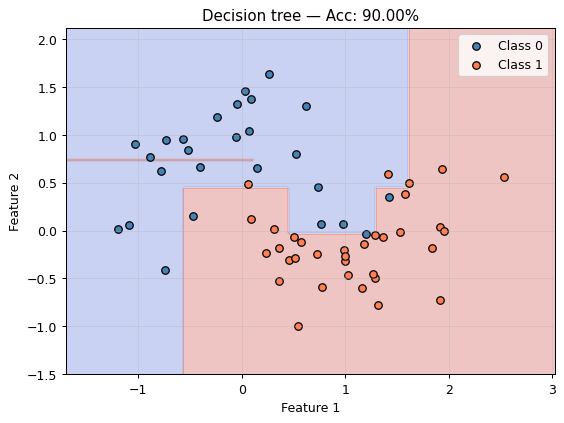

In [22]:
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree.predict(X_test))

print(f'Decision tree accuracy (max_depth=5, test): {acc_tree:.3f}')
print(f'Improvement over logistic regression: +{(acc_tree - acc_logreg)*100:.1f} points')

plot_decision_boundary(tree, X_test, y_test, f'Decision tree — Acc: {acc_tree:.2%}')

Gradient Boosting Accuracy: 0.950


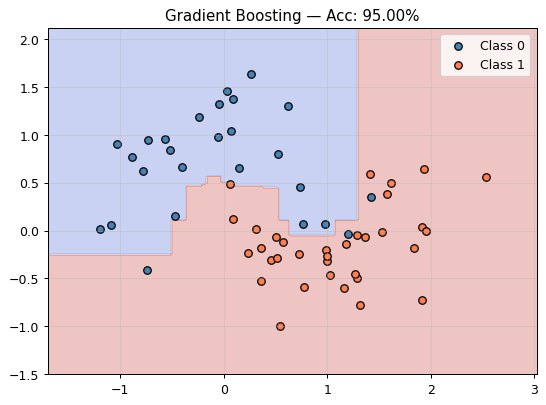

In [32]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Boosting robusto contra el ruido
boosting_model = HistGradientBoostingClassifier(
    max_iter=40,           # Pocos árboles para evitar que memorice el ruido
    learning_rate=0.08,    # Pasos pequeños y seguros
    max_leaf_nodes=7,      # Árboles muy simples (pocos cortes)
    random_state=42
)

boosting_model.fit(X_train, y_train)
acc_boosting = accuracy_score(y_test, boosting_model.predict(X_test))

print(f'Gradient Boosting Accuracy: {acc_boosting:.3f}')
plot_decision_boundary(boosting_model, X_test, y_test, f'Gradient Boosting — Acc: {acc_boosting:.2%}')

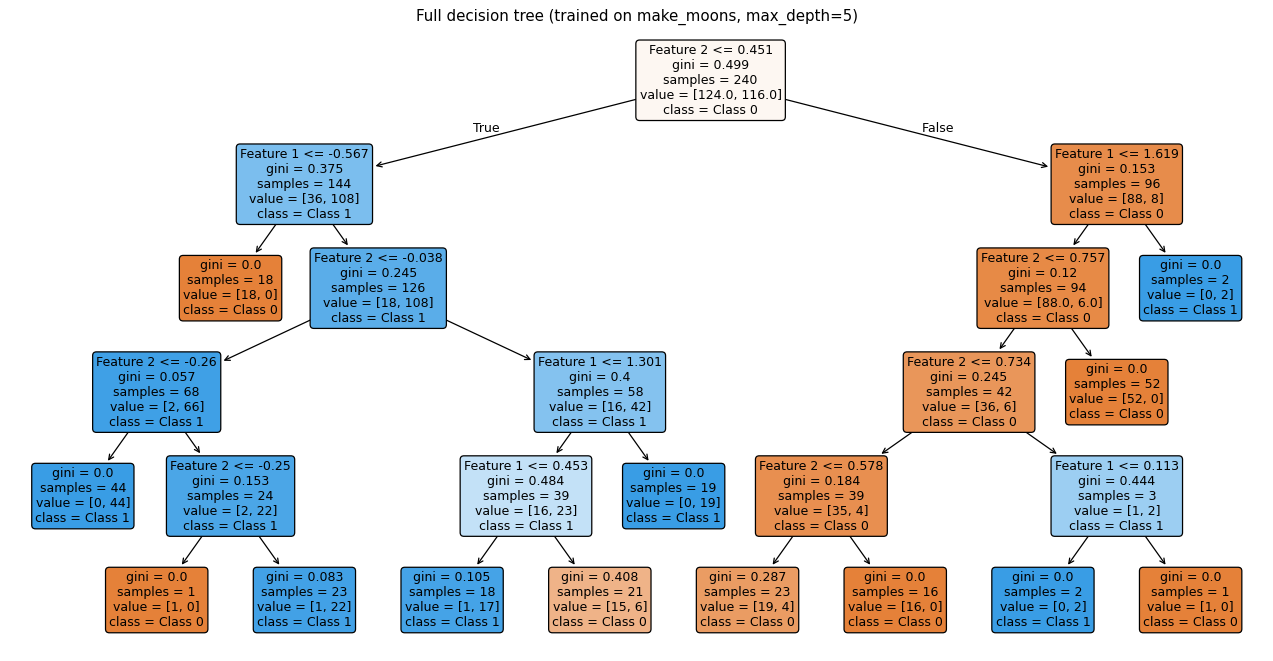

In [33]:
plt.figure(figsize=(18, 9))
plot_tree(
    tree,
    filled=True,
    rounded=True,
    feature_names=['Feature 1', 'Feature 2'],
    class_names=['Class 0', 'Class 1'],
    fontsize=10
)
plt.title('Full decision tree (trained on make_moons, max_depth=5)')
plt.show()

This graph shows how the data was evaluated and classified, it shows what values were considered to decide whether it belongs to class 1 or class 0, for example, feature 2 <= 0.451, is the condition, if its true it goes to a blue box, and if its not then it goes to the orange one, it also metions gini that is a mathematical metric used to measure the "impurity" or randomness of a dataset, the sample are the amount of data used, and values shows how many samples belong to each class, we can also see, that after one conditional, comes another and another and so on, to classify each sample accurately

##EJEMPLOS DEL MUNDIAL